# 🛒 Customer Next Purchase Prediction & Personalized Recommendation System

## Project Overview

This project aims to predict the product category a customer is most likely to purchase next based on their historical purchasing behavior.

The project combines:

- Customer behavior analysis
- Exploratory Data Analysis
- Feature engineering
- Machine learning
- Top-K prediction
- Personalized product recommendations
- Explainable AI

### Dataset

The project uses three main relational datasets:

- Customers
- Products
- Transactions

The `next_purchase_category` target is intentionally not present in the raw data. It will be created from chronological transaction history to avoid data leakage.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
file_path = "C:/Users/sahus/Downloads/customer_next_purchase_dataset.xlsx"

customers = pd.read_excel(file_path, sheet_name="Customers")
products = pd.read_excel(file_path, sheet_name="Products")
transactions = pd.read_excel(file_path, sheet_name="Transactions")

print("Data loaded successfully!")

Data loaded successfully!


In [3]:
# Basic dataset understanding

print("Customers:", customers.shape)
print("Products:", products.shape)
print("Transactions:", transactions.shape)

print("\nCustomer Segments:")
print(customers["customer_segment"].value_counts())

print("\nProduct Categories:")
print(products["category"].value_counts())

print("\nMissing Values:")
print("Customers:\n", customers.isnull().sum())
print("\nProducts:\n", products.isnull().sum())
print("\nTransactions:\n", transactions.isnull().sum())

Customers: (10000, 7)
Products: (500, 8)
Transactions: (55000, 12)

Customer Segments:
customer_segment
Regular       3790
Budget        2187
Occasional    1682
Premium       1538
High Value     803
Name: count, dtype: int64

Product Categories:
category
Electronics           77
Grocery               67
Fashion               51
Mobile Accessories    44
Home & Kitchen        41
Footwear              36
Beauty                34
Sports                34
Computers             27
Books                 25
Home Appliances       18
Office Supplies       15
Personal Care         13
Bags                  11
Gaming                 7
Name: count, dtype: int64

Missing Values:
Customers:
 customer_id          0
age                  0
gender               0
city                 0
state                0
customer_segment     0
registration_date    0
dtype: int64

Products:
 product_id         0
product_name       0
category           0
sub_category       0
brand              0
price              0
cos

In [4]:
# Convert dates
customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

transactions["order_date"] = pd.to_datetime(
    transactions["order_date"]
)

# Remove exact duplicate rows
customers.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
transactions.drop_duplicates(inplace=True)

# Fill missing product ratings with category median
products["product_rating"] = products.groupby(
    "category"
)["product_rating"].transform(
    lambda x: x.fillna(x.median())
)

# Fill missing delivery days with median
transactions["delivery_days"] = transactions[
    "delivery_days"
].fillna(
    transactions["delivery_days"].median()
)

print("Data cleaning completed.")

Data cleaning completed.


In [5]:
df = transactions.merge(
    products,
    on="product_id",
    how="left"
).merge(
    customers,
    on="customer_id",
    how="left"
)

print("Final analysis dataset:", df.shape)

df.head()

Final analysis dataset: (55000, 25)


,transaction_id,customer_id,product_id,order_date,quantity,unit_price,discount_percentage,payment_method,sales_channel,delivery_days,...,brand,price,cost_price,product_rating,age,gender,city,state,customer_segment,registration_date
0,T0000001,C00001,P0465,2025-05-24 03:36:44,2,923.12,1.81,UPI,Online,4.0,...,Wrogn,940.11,679.22,4.20,22,Male,Hyderabad,Telangana,Occasional,2025-05-05 03:36:44
1,T0000002,C00001,P0054,2025-08-13 03:36:44,1,4332.39,13.96,Net Banking,Mobile App,5.0,...,JBL,5035.45,2851.25,3.40,22,Male,Hyderabad,Telangana,Occasional,2025-05-05 03:36:44
2,T0000003,C00002,P0040,2025-04-16 00:00:00,3,272.92,10.41,Debit Card,Online,2.0,...,Himalaya,304.63,231.89,3.95,54,Female,Delhi,Delhi,Occasional,2023-05-31 21:40:15
3,T0048355,C00002,P0427,2025-05-18 00:00:00,1,447.35,11.74,Cash,Online,3.0,...,Lakme,506.86,326.09,3.50,54,Female,Delhi,Delhi,Occasional,2023-05-31 21:40:15
4,T0000004,C00003,P0176,2024-01-26 00:00:00,1,397.01,10.87,Net Banking,Mobile App,1.0,...,Britannia,445.45,313.73,4.20,48,Female,Indore,Madhya Pradesh,Occasional,2023-11-30 11:13:36


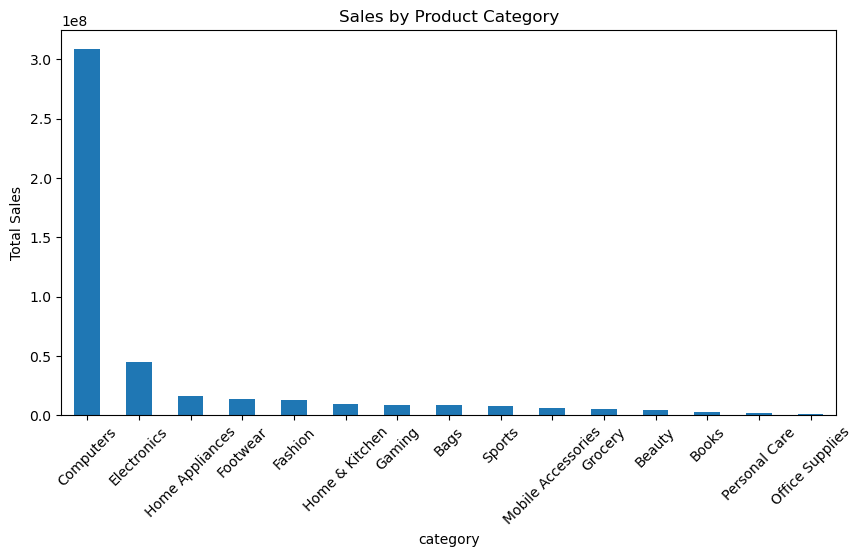

In [6]:
category_sales = (
    df.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
category_sales.plot(kind="bar")
plt.title("Sales by Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

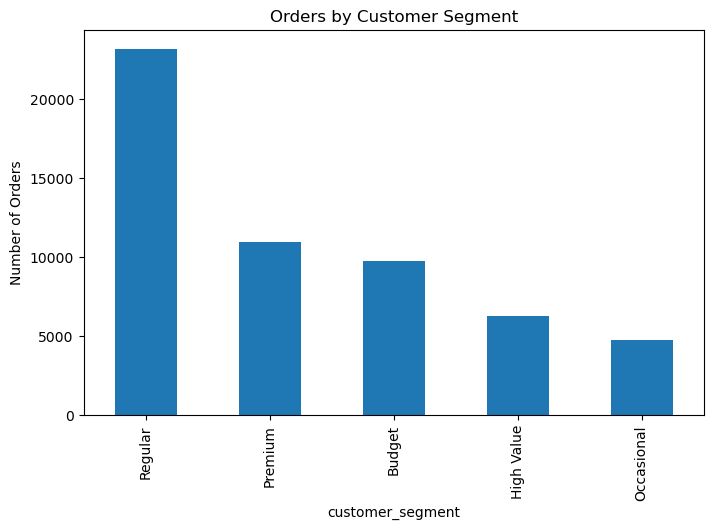

In [7]:
segment_orders = df["customer_segment"].value_counts()

plt.figure(figsize=(8,5))
segment_orders.plot(kind="bar")
plt.title("Orders by Customer Segment")
plt.ylabel("Number of Orders")
plt.show()

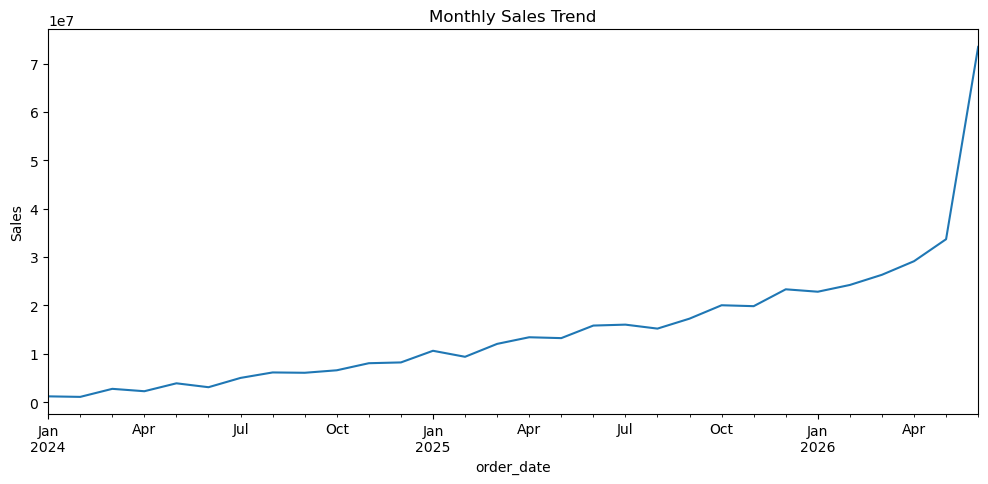

In [8]:
monthly_sales = (
    df.set_index("order_date")
      .resample("ME")["total_amount"]
      .sum()
)

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

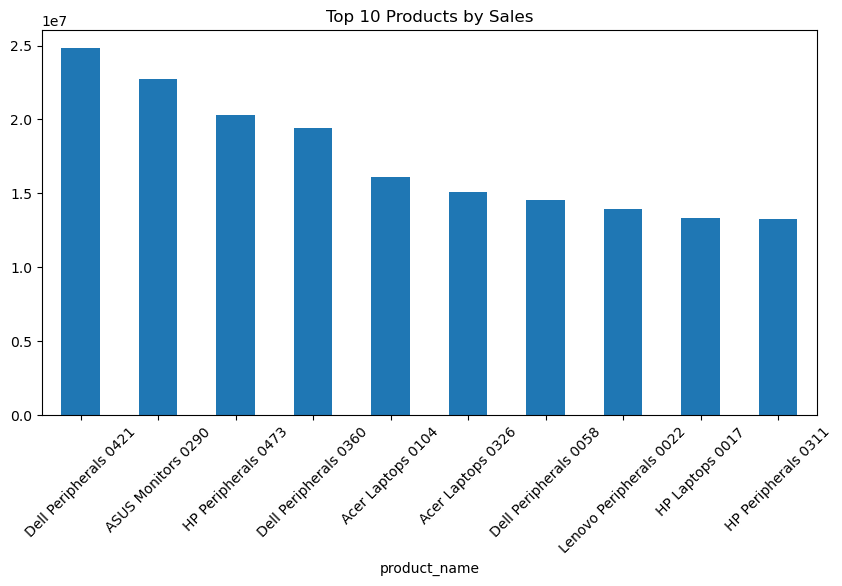

In [9]:
top_products = (
    df.groupby("product_name")["total_amount"]
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xticks(rotation=45)
plt.show()

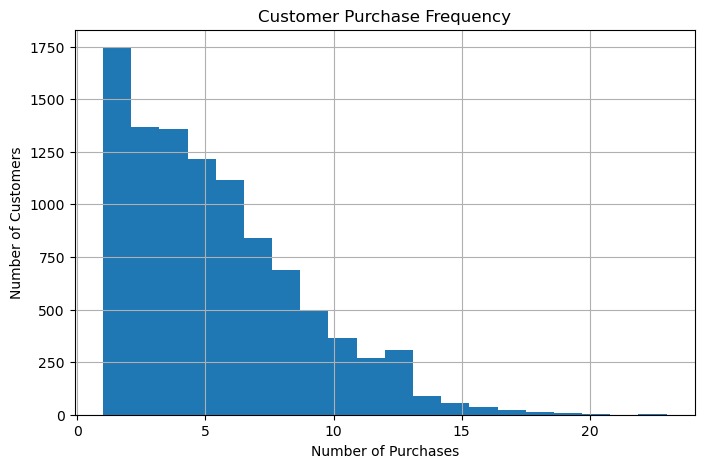

In [10]:
purchase_frequency = (
    df.groupby("customer_id")
    .size()
)

plt.figure(figsize=(8,5))
purchase_frequency.hist(bins=20)
plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
df = df.sort_values(
    ["customer_id", "order_date"]
).reset_index(drop=True)

In [12]:
df["next_purchase_category"] = (
    df.groupby("customer_id")["category"]
    .shift(-1)
)

In [13]:
df[
    ["customer_id", "order_date", "category", "next_purchase_category"]
].head(15)

,customer_id,order_date,category,next_purchase_category
0,C00001,2025-05-24 03:36:44,Fashion,Electronics
1,C00001,2025-08-13 03:36:44,Electronics,NaN
2,C00002,2025-04-16 00:00:00,Personal Care,Beauty
3,C00002,2025-05-18 00:00:00,Beauty,NaN
4,C00003,2024-01-26 00:00:00,Grocery,Computers
5,C00003,2024-02-06 00:00:00,Computers,Mobile Accessories
6,C00003,2024-04-05 00:00:00,Mobile Accessories,Grocery
7,C00003,2024-05-29 00:00:00,Grocery,Electronics
8,C00003,2024-07-07 00:00:00,Electronics,NaN
9,C00004,2024-10-07 00:00:00,Mobile Accessories,Electronics


In [21]:
# Sort transactions chronologically

df = df.sort_values(
    ["customer_id", "order_date"]
).reset_index(drop=True)

df.head()

,transaction_id,customer_id,product_id,order_date,quantity,unit_price,discount_percentage,payment_method,sales_channel,delivery_days,...,price,cost_price,product_rating,age,gender,city,state,customer_segment,registration_date,next_purchase_category
0,T0000001,C00001,P0465,2025-05-24 03:36:44,2,923.12,1.81,UPI,Online,4.0,...,940.11,679.22,4.20,22,Male,Hyderabad,Telangana,Occasional,2025-05-05 03:36:44,Electronics
1,T0000003,C00002,P0040,2025-04-16 00:00:00,3,272.92,10.41,Debit Card,Online,2.0,...,304.63,231.89,3.95,54,Female,Delhi,Delhi,Occasional,2023-05-31 21:40:15,Beauty
2,T0000004,C00003,P0176,2024-01-26 00:00:00,1,397.01,10.87,Net Banking,Mobile App,1.0,...,445.45,313.73,4.20,48,Female,Indore,Madhya Pradesh,Occasional,2023-11-30 11:13:36,Computers
3,T0000005,C00003,P0475,2024-02-06 00:00:00,1,26203.02,7.55,UPI,Mobile App,2.0,...,28343.37,20690.56,3.70,48,Female,Indore,Madhya Pradesh,Occasional,2023-11-30 11:13:36,Mobile Accessories
4,T0000006,C00003,P0493,2024-04-05 00:00:00,1,486.32,1.26,Credit Card,Online,1.0,...,492.53,393.92,3.60,48,Female,Indore,Madhya Pradesh,Occasional,2023-11-30 11:13:36,Grocery


In [22]:
# Keep customers with at least 2 purchases

counts = df["customer_id"].value_counts()

valid_customers = counts[counts >= 2].index

df_model = df[
    df["customer_id"].isin(valid_customers)
].copy()

print("Customers with at least 2 purchases:", df_model["customer_id"].nunique())

Customers with at least 2 purchases: 8257


In [23]:
# Create the next purchase category

df_model["next_purchase_category"] = (
    df_model
    .groupby("customer_id")["category"]
    .shift(-1)
)

df_model[
    ["customer_id", "order_date", "category", "next_purchase_category"]
].head(10)

,customer_id,order_date,category,next_purchase_category
2,C00003,2024-01-26,Grocery,Computers
3,C00003,2024-02-06,Computers,Mobile Accessories
4,C00003,2024-04-05,Mobile Accessories,Grocery
5,C00003,2024-05-29,Grocery,NaN
6,C00004,2024-10-07,Mobile Accessories,Electronics
7,C00004,2024-11-09,Electronics,Mobile Accessories
8,C00004,2025-02-12,Mobile Accessories,Personal Care
9,C00004,2025-03-13,Personal Care,Mobile Accessories
10,C00004,2025-05-03,Mobile Accessories,Personal Care
11,C00004,2025-06-30,Personal Care,Mobile Accessories


In [24]:
# Remove the final transaction of each customer
# because it has no known next purchase

history = df_model.dropna(
    subset=["next_purchase_category"]
).copy()

print("Historical records:", history.shape)

Historical records: (35611, 26)


In [25]:
# Customer-level features

features = history.groupby("customer_id").agg(
    total_orders=("transaction_id", "count"),
    total_spend=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean"),
    avg_quantity=("quantity", "mean"),
    avg_discount=("discount_percentage", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    unique_products=("product_id", "nunique"),
    unique_categories=("category", "nunique"),
    return_rate=("returned", lambda x: (x == "Yes").mean())
).reset_index()

features.head()

,customer_id,total_orders,total_spend,avg_order_value,avg_quantity,avg_discount,avg_delivery_days,unique_products,unique_categories,return_rate
0,C00003,3,27086.35,9028.783333,1.000000,6.560000,1.333333,3,3,0.333333
1,C00004,7,10808.00,1544.000000,1.571429,13.021429,3.428571,7,3,0.000000
2,C00006,4,70012.97,17503.242500,1.500000,11.975000,2.750000,4,4,0.250000
3,C00007,10,23704.63,2370.463000,1.400000,12.631000,1.300000,10,6,0.000000
4,C00010,6,256730.75,42788.458333,2.166667,9.865000,2.666667,6,5,0.166667


In [26]:
# Calculate days since the customer's last purchase

last_purchase = history.groupby(
    "customer_id"
)["order_date"].max().reset_index()

last_purchase["days_since_last_purchase"] = (
    df["order_date"].max()
    - last_purchase["order_date"]
).dt.days

last_purchase.head()

,customer_id,order_date,days_since_last_purchase
0,C00003,2024-04-05 00:00:00,816
1,C00004,2025-09-17 00:00:00,286
2,C00006,2024-07-01 00:00:00,729
3,C00007,2026-06-30 00:00:00,0
4,C00010,2026-06-17 11:26:18,12


In [27]:
# Add recency to customer features

features = features.merge(
    last_purchase[
        ["customer_id", "days_since_last_purchase"]
    ],
    on="customer_id"
)

features.head()

,customer_id,total_orders,total_spend,avg_order_value,avg_quantity,avg_discount,avg_delivery_days,unique_products,unique_categories,return_rate,days_since_last_purchase
0,C00003,3,27086.35,9028.783333,1.000000,6.560000,1.333333,3,3,0.333333,816
1,C00004,7,10808.00,1544.000000,1.571429,13.021429,3.428571,7,3,0.000000,286
2,C00006,4,70012.97,17503.242500,1.500000,11.975000,2.750000,4,4,0.250000,729
3,C00007,10,23704.63,2370.463000,1.400000,12.631000,1.300000,10,6,0.000000,0
4,C00010,6,256730.75,42788.458333,2.166667,9.865000,2.666667,6,5,0.166667,12


In [28]:
# Actual next purchase category

target = (
    df_model
    .groupby("customer_id")
    .tail(1)[
        ["customer_id", "category"]
    ]
    .rename(
        columns={
            "category": "next_purchase_category"
        }
    )
)

target.head()

,customer_id,next_purchase_category
5,C00003,Grocery
13,C00004,Computers
19,C00006,Fashion
30,C00007,Home & Kitchen
38,C00010,Books


In [29]:
# Combine features and target

ml_data = features.merge(
    target,
    on="customer_id"
)

print("ML dataset:", ml_data.shape)

ml_data.head()

ML dataset: (8257, 12)


,customer_id,total_orders,total_spend,avg_order_value,avg_quantity,avg_discount,avg_delivery_days,unique_products,unique_categories,return_rate,days_since_last_purchase,next_purchase_category
0,C00003,3,27086.35,9028.783333,1.000000,6.560000,1.333333,3,3,0.333333,816,Grocery
1,C00004,7,10808.00,1544.000000,1.571429,13.021429,3.428571,7,3,0.000000,286,Computers
2,C00006,4,70012.97,17503.242500,1.500000,11.975000,2.750000,4,4,0.250000,729,Fashion
3,C00007,10,23704.63,2370.463000,1.400000,12.631000,1.300000,10,6,0.000000,0,Home & Kitchen
4,C00010,6,256730.75,42788.458333,2.166667,9.865000,2.666667,6,5,0.166667,12,Books


In [30]:
# Check target distribution

print(
    ml_data["next_purchase_category"]
    .value_counts()
)

next_purchase_category
Electronics           1101
Grocery                977
Fashion                892
Home & Kitchen         729
Mobile Accessories     630
Beauty                 609
Computers              594
Footwear               528
Sports                 414
Bags                   362
Books                  327
Home Appliances        311
Personal Care          278
Office Supplies        259
Gaming                 246
Name: count, dtype: int64


In [31]:
# Separate features and target

X = ml_data.drop(
    columns=["customer_id", "next_purchase_category"]
)

y = ml_data["next_purchase_category"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (8257, 10)
Target shape: (8257,)


In [32]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

Classes:
['Bags' 'Beauty' 'Books' 'Computers' 'Electronics' 'Fashion' 'Footwear'
 'Gaming' 'Grocery' 'Home & Kitchen' 'Home Appliances'
 'Mobile Accessories' 'Office Supplies' 'Personal Care' 'Sports']


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (6605, 10)
Testing data : (1652, 10)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [35]:
# Baseline: predict the most common category

from sklearn.metrics import accuracy_score

most_common_class = y_train[0]

baseline_predictions = np.full(
    len(y_test),
    most_common_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline Accuracy:", round(baseline_accuracy * 100, 2), "%")

Baseline Accuracy: 11.86 %


In [36]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_scaled,
    y_train
)

log_pred = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(
    y_test,
    log_pred
)

print("Logistic Regression Accuracy:",
      round(log_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 12.71 %


In [37]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 10.11 %


In [40]:
# XGBoost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:",
      round(xgb_accuracy * 100, 2), "%")

XGBoost Accuracy: 11.74 %


In [41]:
# Model comparison

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        baseline_accuracy,
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

results["Accuracy"] = (
    results["Accuracy"] * 100
).round(2)

results.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy
1,Logistic Regression,12.71
0,Baseline,11.86
3,XGBoost,11.74
2,Random Forest,10.11


In [42]:
from sklearn.metrics import classification_report

best_model = xgb_model
best_pred = xgb_pred

print(
    classification_report(
        y_test,
        best_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

              Bags       0.00      0.00      0.00        72
            Beauty       0.09      0.07      0.08       122
             Books       0.00      0.00      0.00        65
         Computers       0.15      0.18      0.16       119
       Electronics       0.15      0.32      0.20       220
           Fashion       0.12      0.17      0.14       178
          Footwear       0.07      0.04      0.05       106
            Gaming       0.06      0.02      0.03        49
           Grocery       0.14      0.21      0.17       196
    Home & Kitchen       0.07      0.07      0.07       146
   Home Appliances       0.05      0.02      0.02        62
Mobile Accessories       0.05      0.03      0.04       126
   Office Supplies       0.12      0.02      0.03        52
     Personal Care       0.00      0.00      0.00        56
            Sports       0.04      0.02      0.03        83

          accuracy                    

<Figure size 1200x1000 with 0 Axes>

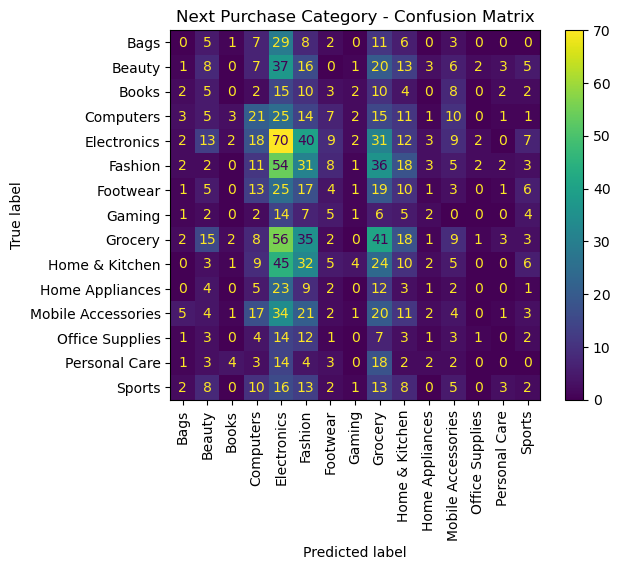

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=90
)

plt.title("Next Purchase Category - Confusion Matrix")
plt.show()

In [44]:
# Top-K evaluation

probabilities = xgb_model.predict_proba(X_test)

top3 = np.argsort(
    probabilities,
    axis=1
)[:, -3:]

top5 = np.argsort(
    probabilities,
    axis=1
)[:, -5:]

top3_accuracy = np.mean([
    actual in predictions
    for actual, predictions in zip(y_test, top3)
])

top5_accuracy = np.mean([
    actual in predictions
    for actual, predictions in zip(y_test, top5)
])

print("Top-1 Accuracy:",
      round(xgb_accuracy * 100, 2), "%")

print("Top-3 Accuracy:",
      round(top3_accuracy * 100, 2), "%")

print("Top-5 Accuracy:",
      round(top5_accuracy * 100, 2), "%")

Top-1 Accuracy: 11.74 %
Top-3 Accuracy: 32.75 %
Top-5 Accuracy: 49.76 %


In [45]:
# Feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
2,avg_order_value,0.106470
1,total_spend,0.102324
4,avg_discount,0.102218
9,days_since_last_purchase,0.101910
3,avg_quantity,0.100168
6,unique_products,0.098986
5,avg_delivery_days,0.098833
8,return_rate,0.098112
0,total_orders,0.095925
7,unique_categories,0.095055


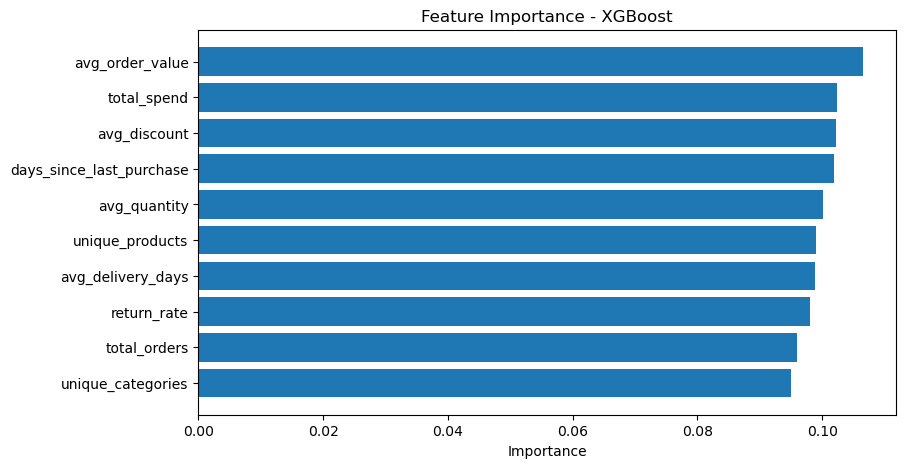

In [46]:
plt.figure(figsize=(9, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")

plt.show()

In [47]:
# Customer next-purchase prediction function

def predict_next_purchase(customer_id):

    customer = ml_data[
        ml_data["customer_id"] == customer_id
    ]

    if customer.empty:
        return "Customer not found."

    customer_features = customer.drop(
        columns=[
            "customer_id",
            "next_purchase_category"
        ]
    )

    probabilities = xgb_model.predict_proba(
        customer_features
    )[0]

    top_indices = np.argsort(
        probabilities
    )[-5:][::-1]

    recommendations = pd.DataFrame({
        "Category": label_encoder.inverse_transform(
            top_indices
        ),
        "Probability": (
            probabilities[top_indices] * 100
        ).round(2)
    })

    return recommendations

In [48]:
# Test with a customer

customer_id = ml_data["customer_id"].iloc[0]

print("Customer:", customer_id)

predict_next_purchase(customer_id)

Customer: C00003


,Category,Probability
0,Grocery,58.00
1,Computers,7.79
2,Bags,4.93
3,Home Appliances,4.86
4,Fashion,4.24


In [49]:
def recommend_products(customer_id, n=5):

    predictions = predict_next_purchase(customer_id)

    if isinstance(predictions, str):
        return predictions

    top_category = predictions.iloc[0]["Category"]

    recommended = products[
        products["category"] == top_category
    ][
        ["product_id", "product_name",
         "brand", "price", "product_rating"]
    ].sort_values(
        "product_rating",
        ascending=False
    ).head(n)

    return recommended

In [50]:
customer_id = ml_data["customer_id"].iloc[0]

print("Customer:", customer_id)

print("\nPredicted Categories:")
display(
    predict_next_purchase(customer_id)
)

print("\nRecommended Products:")
display(
    recommend_products(customer_id)
)

Customer: C00003

Predicted Categories:


,Category,Probability
0,Grocery,58.00
1,Computers,7.79
2,Bags,4.93
3,Home Appliances,4.86
4,Fashion,4.24



Recommended Products:


,product_id,product_name,brand,price,product_rating
34,P0035,Amul Staples 0035,Amul,325.50,4.9
303,P0304,Nestle Snacks 0304,Nestle,809.74,4.8
105,P0106,Nestle Snacks 0106,Nestle,774.57,4.8
253,P0254,Nestle Snacks 0254,Nestle,691.22,4.8
8,P0009,Aashirvaad Beverages 0009,Aashirvaad,435.55,4.8
